# (연구) HST example 1, Appendix 추가
> 완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- hide: false
- categories: [기하학적 딥러닝, 논문연구]

### Import

In [28]:
import heavysnow as hs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rc('image', cmap='gray')
import rpy2 
%load_ext rpy2.ipython
%run pybase

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


### Data 

In [2]:
f=np.array([-1,-1,-1,1,-1,-1,-1,1,1,1,-1,1,1,1])*1.0
n=len(f)
V=list(range(n))
W=np.zeros([n,n])
for i in range(n):
    for j in range(n):
        if abs(i-j)==1: W[i,j]=1
W[0,0]=0.5
W[n-1,n-1]=0.5

In [3]:
gs=hs.GraphSignal(V,W,f)

In [4]:
gs.initdist=np.array([1/n]*n)

### HST

In [5]:
hst=hs.HeavySnowTransform(gs)
hst.snow(tau=80000,b=0.03)

HST (tau= 80000, b=0.03)
80000/80000
HST completed and all history is recorded.


### 시각화를 위해서 R로 자료를 옮김

In [16]:
maxtau=hst.tau
W_Graph=hst.graphweight
W_Euclid=hst.euclidweight
W_HST=hst.snowweight
V=np.array(hst.V)
f=hst.f
n=hst.n
%R -i maxtau,W_Graph,W_Euclid,W_HST,V,f,n

### R을 활용한 시각화 (1): 원래자료 

R[write to console]: ── Attaching packages ─────────────────────────────────────── tidyverse 1.3.1 ──

R[write to console]: ✔ ggplot2 3.3.5     ✔ purrr   0.3.4
✔ tibble  3.1.2     ✔ dplyr   1.0.7
✔ tidyr   1.1.3     ✔ stringr 1.4.0
✔ readr   1.4.0     ✔ forcats 0.5.1

R[write to console]: ── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()

R[write to console]: 
Attaching package: ‘gridExtra’


R[write to console]: The following object is masked from ‘package:dplyr’:

    combine


R[write to console]: 
Attaching package: ‘lubridate’


R[write to console]: The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union




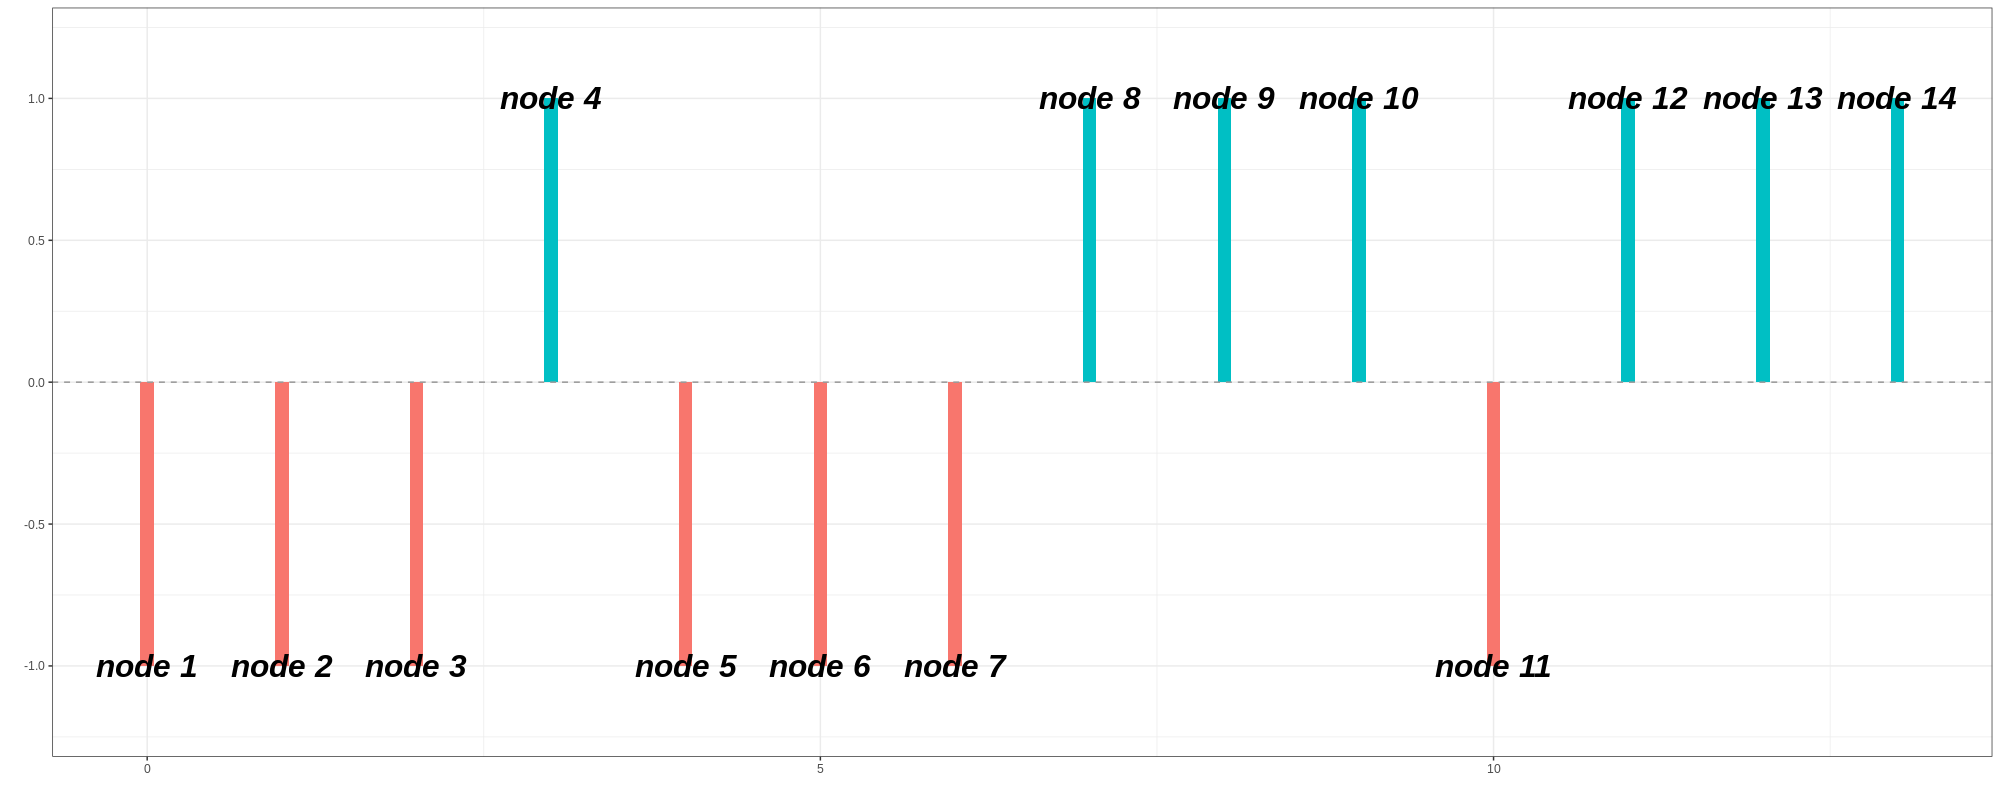

In [17]:
%%R -w 2000 -h 800 -r 100
library(tidyverse)
library(latex2exp)
library(gridExtra)
source('rbase.R')
Vtext=str_c('node ',V+1)
fig0<-ggplot(data=tibble(V=V,f=f,Vtext=Vtext),aes(x=V,y=f,label=Vtext))+
geom_col(aes(fill=(f>0)),width=0.1)+geom_hline(aes(yintercept=0),col="gray60",lty=2)+
geom_text(fontface = 4,size=8)+
xlab("")+ylab("")+guides(fill=FALSE)+theme(plot.title=element_text(face="bold.italic"))+theme_bw()+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 15, color = "black", face = "bold.italic"))+
ylim(-1.2,1.2)+
theme(plot.title=element_text(face="bold.italic"))
#ggsave(plot=p0,"./fig/2021-0217_fig0.pdf",width=20,height=6)
fig0

### R을 활용한 시각화 (2): Weight matrix 와 Eigen plot 

`-` `ggplot`에서 `geom_tile`을 사용하기 위해서 매트릭스 형태인 `W_Graph`, `W_Euclid`, `W_HST`를 길게 펼친다. 결과를 각각 `W_Graph_long`, `W_Euclid_long`, `W_HST_long`에 저장한다. 

In [18]:
%%R
grid<-expand.grid(x=1:n,y=1:n)
W_Graph_long<-as_tibble(cbind(grid,as.vector(W_Graph)));names(W_Graph_long)<-c("x","y","W")
W_Euclid_long<-as_tibble(cbind(grid,as.vector(W_Euclid)));names(W_Euclid_long)<-c("x","y","W")
W_HST_long<-as_tibble(cbind(grid,as.vector(W_HST)));names(W_HST_long)<-c("x","y","W")

`-` 그래프퓨리에 변환: $(\bf{f},\bf{W})$에 그래프 퓨리에 변환을 수행함.  

In [19]:
%%R
source('heavysnow.R')
gfftrslt_Euclid<-gfft(f,W_Euclid)
gfftrslt_Graph<-gfft(f,W_Graph)
gfftrslt_HST<-gfft(f,W_HST)

R[write to console]: 
Attaching package: ‘kohonen’


R[write to console]: The following object is masked from ‘package:purrr’:

    map




`-` 그래프 퓨리에 변환의 결과 고유치, 고유벡터, $\bf{\bar{f}}$가 반환됨. 

In [20]:
%%R
head(gfftrslt_HST)

$λ
 [1] 1.981431e+00 1.972712e+00 1.947041e+00 1.940049e+00 1.077878e+00
 [6] 1.071317e+00 9.686805e-01 9.570847e-01 4.303983e-02 4.063528e-02
[11] 8.670486e-05 4.505732e-05 4.878586e-15 3.985421e-17

$Ψ
               [,1]          [,2]          [,3]          [,4]          [,5]
 [1,] -3.573562e-01  5.947338e-05 -3.743486e-01 -8.647004e-05  1.823492e-04
 [2,]  4.980447e-01 -8.212889e-05  5.029005e-01  1.152807e-04 -1.744100e-05
 [3,] -3.599693e-01  5.749614e-05 -3.181430e-01 -7.079042e-05 -1.973529e-04
 [4,] -1.797357e-11  1.812139e-10  1.631999e-11  3.092872e-10 -7.074061e-10
 [5,]  3.113455e-01 -2.687793e-05 -2.673771e-01 -8.772150e-05  2.624705e-04
 [6,] -4.946451e-01  3.794607e-05  5.091143e-01  1.603788e-04  4.053101e-06
 [7,]  3.912292e-01 -2.703293e-05 -4.183912e-01 -1.271742e-04 -1.904071e-04
 [8,] -5.314455e-05 -2.635870e-01  1.110563e-04 -4.419308e-01  5.429324e-01
 [9,]  7.038462e-05  3.758355e-01 -1.470221e-04  6.062385e-01 -2.767507e-02
[10,] -4.799516e-05 -2.741149e-01  9

`-` 시각화코드 

TableGrob (2 x 3) "arrange": 6 grobs
  z     cells    name           grob
1 1 (1-1,1-1) arrange gtable[layout]
2 2 (1-1,2-2) arrange gtable[layout]
3 3 (1-1,3-3) arrange gtable[layout]
4 4 (2-2,1-1) arrange gtable[layout]
5 5 (2-2,2-2) arrange gtable[layout]
6 6 (2-2,3-3) arrange gtable[layout]


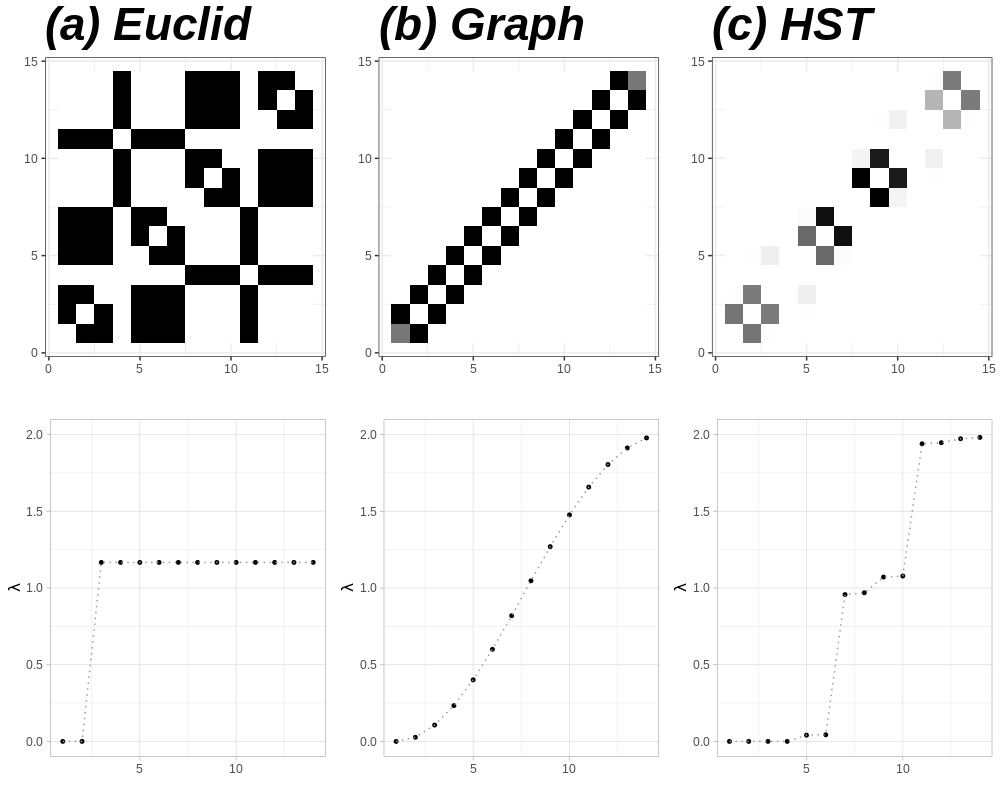

In [21]:
%%R -w 1000 -h 800 -r 100
library(gridExtra)

fig1_1<-ggplot()+geom_tile(data=W_Euclid_long,aes(x=x,y=y,fill=W))+theme_bw()+xlab("")+ylab("")+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))+
scale_fill_gradient2(low="white",high="black")+
labs(fill=TeX('$W$'))+
theme(legend.position="none")+theme(legend.key=element_blank())+
ggtitle("(a) Euclid")+theme(plot.title=element_text(face="bold.italic",size=rel(3)))

fig1_2<-ggplot()+geom_tile(data=W_Graph_long,aes(x=x,y=y,fill=W))+theme_bw()+xlab("")+ylab("")+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))+
scale_fill_gradient2(low="white",high="black")+
labs(fill=TeX('$\\hat{W}$'))+
theme(legend.position="none")+theme(legend.key=element_blank())+
ggtitle("(b) Graph")+theme(plot.title=element_text(face="bold.italic",size=rel(3)))

fig1_3<-ggplot()+geom_tile(data=W_HST_long,aes(x=x,y=y,fill=W))+theme_bw()+xlab("")+ylab("")+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 20, color = "black", face = "bold.italic"))+
scale_fill_gradient2(low="white",high="black")+
labs(fill=TeX('$\\hat{W}(\\tau)$'))+
theme(legend.position="none")+theme(legend.key=element_blank())+
ggtitle("(c) HST")+theme(plot.title=element_text(face="bold.italic",size=rel(3)))

fig1_4<-eigenplot(gfftrslt_Euclid)+ylim(0,2)+theme_light()
fig1_5<-eigenplot(gfftrslt_Graph)+ylim(0,2)+theme_light()
fig1_6<-eigenplot(gfftrslt_HST)+ylim(0,2)+theme_light()
fig1=grid.arrange(fig1_1,fig1_2,fig1_3,fig1_4,fig1_5,fig1_6,ncol=3,nrow=2)
fig1
#ggsave(plot=fig1,"asdf2.pdf",width=15,height=10)

### R을 활용한 시각화 (3): Decomposition 

`-` 디콤포지션을 수행하고 결과를 저장: $(\bf{f},\bf{W})$에 decomposition을 수행하고 그 결과를 각각 `decomprslt_Euclid`, `decomprslt_Graph`, `decomprslt_HST`에 저장한다. 

In [22]:
%%R 
decomprslt_Euclid<-decompose(f,W_Euclid,V=1:n) # 0, 35000, 60000, 80000
decomprslt_Graph<-decompose(f,W_Graph,V=1:n) # 0, 35000, 60000, 80000
decomprslt_HST<-decompose(f,W_HST,V=1:n) # 0, 35000, 60000, 80000

Note: Using an external vector in selections is ambiguous.
ℹ Use `all_of(n)` instead of `n` to silence this message.
ℹ See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.
This message is displayed once per session.


`-` 디콤포지션 결과는 아래와 같은 형태임 

In [23]:
%%R
head(decomprslt_Euclid)

# A tibble: 6 x 5
      V Vindex eigenvectorindex      fhat eigenvalue
  <int>  <int>            <dbl>     <dbl>      <dbl>
1     1      1                1  8.02e-18   4.04e-18
2     2      2                1  2.04e-16   4.04e-18
3     3      3                1 -1.94e-16   4.04e-18
4     4      4                1  1.00e+ 0   4.04e-18
5     5      5                1 -3.67e-17   4.04e-18
6     6      6                1  1.20e-16   4.04e-18


In [24]:
%%R 
decomprslt_Euclid$method="Euclid"
decomprslt_Graph$method="Graph"
decomprslt_HST$method="HST"
decomprslt<-rbind(decomprslt_Euclid,decomprslt_Graph,decomprslt_HST)

`-` 디콤포지션결과를 시각화한다. `geom_col`과 `facet_grid`를 이용. 

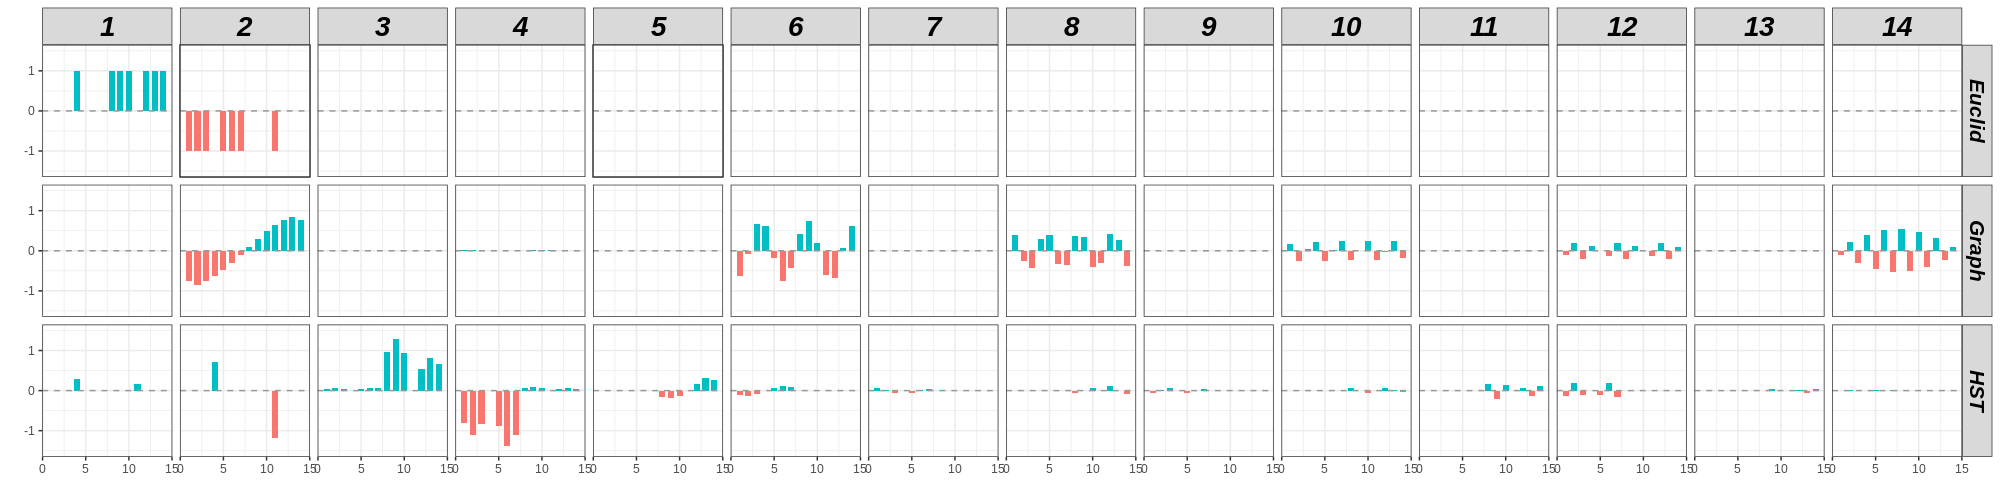

In [25]:
%%R -w 2000 -h 500 -r 100
fig2<-ggplot(data=decomprslt,aes(x=V,y=fhat))+
geom_col(aes(fill=fhat>0),width=0.7)+facet_grid(method~eigenvectorindex)+geom_hline(aes(yintercept=0),col="gray60",lty=2)+
xlab("")+ylab("")+guides(fill=FALSE)+theme(plot.title=element_text(face="bold.italic"))+theme_bw()+
theme(strip.text.x = element_text(size = 20, color = "black", face = "bold.italic"))+
theme(strip.text.y = element_text(size = 15, color = "black", face = "bold.italic"))+
ylim(-1.5,1.5)+
theme(plot.title=element_text(face="bold.italic"))
fig2
#ggsave(plot=fig2,"asdf.pdf",width=20,height=6)

### Appendix 

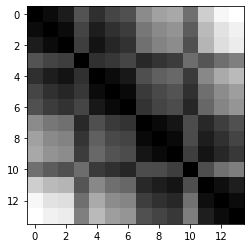

In [29]:
plt.imshow(hst.snowdistance)

In [45]:
hst.snowygrounds_f.iloc[:,0:10]

,h0,h1,h2,h3,h4,h5,h6,h7,h8,h9
0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
1,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
2,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
3,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
5,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
6,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0,-1.0
7,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
9,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [86]:
print(np.max(l2distance(hst.snowygrounds_sumxi.iloc[:,0:100])/(100*hst.b**2)))
print(np.max(l2distance(hst.snowygrounds_sumxi.iloc[:,0:1000])/(1000*hst.b**2)))
print(np.max(l2distance(hst.snowygrounds_sumxi.iloc[:,0:10000])/(10000*hst.b**2)))
print(np.max(l2distance(hst.snowygrounds_sumxi.iloc[:,0:15000])/(15000*hst.b**2)))
print(np.max(l2distance(hst.snowygrounds_sumxi.iloc[:,0:20000])/(20000*hst.b**2)))
print(np.max(l2distance(hst.snowygrounds_sumxi.iloc[:,0:25000])/(25000*hst.b**2)))
print(np.max(l2distance(hst.snowygrounds_sumxi.iloc[:,0:30000])/(30000*hst.b**2)))
print(np.max(l2distance(hst.snowygrounds_sumxi.iloc[:,0:35000])/(35000*hst.b**2)))
print(np.max(l2distance(hst.snowygrounds_sumxi.iloc[:,0:40000])/(40000*hst.b**2)))
print(np.max(l2distance(hst.snowygrounds_sumxi.iloc[:,0:45000])/(45000*hst.b**2)))
print(np.max(l2distance(hst.snowygrounds_sumxi.iloc[:,0:50000])/(50000*hst.b**2)))

77.00000000000011
3143.4799999999827
4359.056799999586
4424.075533333088
4444.0643500002225
4448.094120000684
4464.635566667707
4471.146428572605
4492.003225001255
4507.282666667912
4503.7909200012255


In [73]:
l2distance(hst.snowygrounds_sumxi.iloc[:,0:10000])/(10000*hst.b**2)

array([[0.0000000e+00, 3.2614000e+00, 7.6777000e+00, 4.1191171e+03,
        1.7526400e+01, 3.5946700e+01, 4.0256700e+01, 4.0667428e+03,
        4.0418999e+03, 4.0648102e+03, 3.6139800e+01, 4.0279801e+03,
        3.9831766e+03, 4.1053264e+03],
       [3.2614000e+00, 0.0000000e+00, 3.1545000e+00, 4.2205471e+03,
        1.4394800e+01, 3.2969300e+01, 3.7373100e+01, 4.1676976e+03,
        4.1425805e+03, 4.1661128e+03, 3.2864000e+01, 4.1298297e+03,
        4.0855106e+03, 4.2093182e+03],
       [7.6777000e+00, 3.1545000e+00, 0.0000000e+00, 4.1780290e+03,
        1.4335500e+01, 3.4355400e+01, 3.8672600e+01, 4.1274659e+03,
        4.1027654e+03, 4.1258819e+03, 3.2456300e+01, 4.0927438e+03,
        4.0512359e+03, 4.1745213e+03],
       [4.1191171e+03, 4.2205471e+03, 4.1780290e+03, 0.0000000e+00,
        4.2697163e+03, 4.3590568e+03, 4.3261114e+03, 1.3656100e+01,
        1.9049000e+01, 2.1374700e+01, 4.2751079e+03, 4.3280800e+01,
        7.3509500e+01, 7.7423300e+01],
       [1.7526400e+01, 1.439

In [34]:
hst.snowdistance1/(hst.tau*b**2)

array([[   0. ,    0. ,    0. , 4444.5,    0. ,    0. ,    0. , 4444.5,
        4444.5, 4444.5,    0. , 4444.5, 4444.5, 4444.5],
       [   0. ,    0. ,    0. , 4444.5,    0. ,    0. ,    0. , 4444.5,
        4444.5, 4444.5,    0. , 4444.5, 4444.5, 4444.5],
       [   0. ,    0. ,    0. , 4444.5,    0. ,    0. ,    0. , 4444.5,
        4444.5, 4444.5,    0. , 4444.5, 4444.5, 4444.5],
       [4444.5, 4444.5, 4444.5,    0. , 4444.5, 4444.5, 4444.5,    0. ,
           0. ,    0. , 4444.5,    0. ,    0. ,    0. ],
       [   0. ,    0. ,    0. , 4444.5,    0. ,    0. ,    0. , 4444.5,
        4444.5, 4444.5,    0. , 4444.5, 4444.5, 4444.5],
       [   0. ,    0. ,    0. , 4444.5,    0. ,    0. ,    0. , 4444.5,
        4444.5, 4444.5,    0. , 4444.5, 4444.5, 4444.5],
       [   0. ,    0. ,    0. , 4444.5,    0. ,    0. ,    0. , 4444.5,
        4444.5, 4444.5,    0. , 4444.5, 4444.5, 4444.5],
       [4444.5, 4444.5, 4444.5,    0. , 4444.5, 4444.5, 4444.5,    0. ,
           0. ,    0. , 4